#📌 Extracción

In [208]:

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
else:
    raise Exception(f"Error al obtener datos: {response.status_code}")

df = pd.json_normalize(data)
df.head()


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


#🔧 Transformación

In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [210]:
# Cambio los nombres de las columnas para mayor comodidad en el análisis
df.rename(columns={
    'customer.gender'        : 'Genero',
    'customer.SeniorCitizen' : 'CiudadanoSenior',
    'customer.Partner'       : 'Pareja',
    'customer.Dependents'    : 'Dependientes',
    'customer.tenure'        : 'MesesContrato',
    'phone.PhoneService'     : 'ServicioTelefono',
    'phone.MultipleLines'    : 'Multilinea',
    'internet.InternetService'  : 'ServicioInternet',
    'internet.OnlineSecurity'   : 'SeguridadOnline',
    'internet.OnlineBackup'     : 'OnlineBackup',
    'internet.DeviceProtection' : 'ProteccionDispositivo',
    'internet.TechSupport'      : 'Soporte',
    'internet.StreamingTV'      : 'StreamingTV',
    'internet.StreamingMovies'  : 'StreamingMovies',
    'account.Contract'          : 'TipoContrato',
    'account.PaperlessBilling'  : 'CuentaOnline',
    'account.PaymentMethod'     : 'MetodoPago',
    'account.Charges.Monthly'   : 'CargoMensual',
    'account.Charges.Total'     : 'CargosTotal',
    'Churn'                     : 'Abandono'

}, inplace=True)

print('Columnas finales:', df.columns.tolist())

Columnas finales: ['customerID', 'Abandono', 'Genero', 'CiudadanoSenior', 'Pareja', 'Dependientes', 'MesesContrato', 'ServicioTelefono', 'Multilinea', 'ServicioInternet', 'SeguridadOnline', 'OnlineBackup', 'ProteccionDispositivo', 'Soporte', 'StreamingTV', 'StreamingMovies', 'TipoContrato', 'CuentaOnline', 'MetodoPago', 'CargoMensual', 'CargosTotal']


In [211]:
# Visualizo las nuevas columnas
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customerID             7267 non-null   object 
 1   Abandono               7267 non-null   object 
 2   Genero                 7267 non-null   object 
 3   CiudadanoSenior        7267 non-null   int64  
 4   Pareja                 7267 non-null   object 
 5   Dependientes           7267 non-null   object 
 6   MesesContrato          7267 non-null   int64  
 7   ServicioTelefono       7267 non-null   object 
 8   Multilinea             7267 non-null   object 
 9   ServicioInternet       7267 non-null   object 
 10  SeguridadOnline        7267 non-null   object 
 11  OnlineBackup           7267 non-null   object 
 12  ProteccionDispositivo  7267 non-null   object 
 13  Soporte                7267 non-null   object 
 14  StreamingTV            7267 non-null   object 
 15  Stre

,customerID,Abandono,Genero,CiudadanoSenior,Pareja,Dependientes,MesesContrato,ServicioTelefono,Multilinea,ServicioInternet,...,OnlineBackup,ProteccionDispositivo,Soporte,StreamingTV,StreamingMovies,TipoContrato,CuentaOnline,MetodoPago,CargoMensual,CargosTotal
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [212]:
# Identificación de valores únicos para determinar incoherencias

for column in df.columns:
    unique_values = df[column].unique()
    num_unique = len(unique_values)

    print(f"Columna '{column}':")
    if num_unique < 50:
        print(f"  Valores únicos ({num_unique}): {unique_values}")
    else:
        print(f"  Número de valores únicos: {num_unique}")
    print('-' * 50)

Columna 'customerID':
  Número de valores únicos: 7267
--------------------------------------------------
Columna 'Abandono':
  Valores únicos (3): ['No' 'Yes' '']
--------------------------------------------------
Columna 'Genero':
  Valores únicos (2): ['Female' 'Male']
--------------------------------------------------
Columna 'CiudadanoSenior':
  Valores únicos (2): [0 1]
--------------------------------------------------
Columna 'Pareja':
  Valores únicos (2): ['Yes' 'No']
--------------------------------------------------
Columna 'Dependientes':
  Valores únicos (2): ['Yes' 'No']
--------------------------------------------------
Columna 'MesesContrato':
  Número de valores únicos: 73
--------------------------------------------------
Columna 'ServicioTelefono':
  Valores únicos (2): ['Yes' 'No']
--------------------------------------------------
Columna 'Multilinea':
  Valores únicos (3): ['No' 'Yes' 'No phone service']
--------------------------------------------------
Columna 

In [213]:
# Mapeo para traducir los conceptos en inglés al español
df['Genero'] = df['Genero'].replace({'Female': 'Femenino', 'Male': 'Masculino'})

df['Multilinea'] = df['Multilinea'].replace({'No phone service': 'Sin servicio telefono'})

df['ServicioInternet'] = df['ServicioInternet'].replace({'Fiber optic': 'Fibra Optica', 'No internet service': 'Sin servicio internet'})

df['TipoContrato'] = df['TipoContrato'].replace({'One year': 'Un año', 'Month-to-month': 'Mes a mes', 'Two year': 'Dos años'})

df['MetodoPago'] = df['MetodoPago'].replace({
    'Mailed check': 'Cuenta por correo',
    'Electronic check': 'Cuenta electronica',
    'Credit card (automatic)': 'Tarjeta de credito (automatica)',
    'Bank transfer (automatic)': 'Transferencia bancaria (automatica)'
})

print("Valores únicos después de la traducción:")
print(f"Genero: {df['Genero'].unique()}")
print(f"Multilinea: {df['Multilinea'].unique()}")
print(f"ServicioInternet: {df['ServicioInternet'].unique()}")
print(f"TipoContrato: {df['TipoContrato'].unique()}")
print(f"MetodoPago: {df['MetodoPago'].unique()}")

Valores únicos después de la traducción:
Genero: ['Femenino' 'Masculino']
Multilinea: ['No' 'Yes' 'Sin servicio telefono']
ServicioInternet: ['DSL' 'Fibra Optica' 'No']
TipoContrato: ['Un año' 'Mes a mes' 'Dos años']
MetodoPago: ['Cuenta por correo' 'Cuenta electronica'
 'Tarjeta de credito (automatica)' 'Transferencia bancaria (automatica)']


In [214]:
df.head()

,customerID,Abandono,Genero,CiudadanoSenior,Pareja,Dependientes,MesesContrato,ServicioTelefono,Multilinea,ServicioInternet,...,OnlineBackup,ProteccionDispositivo,Soporte,StreamingTV,StreamingMovies,TipoContrato,CuentaOnline,MetodoPago,CargoMensual,CargosTotal
0,0002-ORFBO,No,Femenino,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,Un año,Yes,Cuenta por correo,65.6,593.3
1,0003-MKNFE,No,Masculino,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Mes a mes,No,Cuenta por correo,59.9,542.4
2,0004-TLHLJ,Yes,Masculino,0,No,No,4,Yes,No,Fibra Optica,...,No,Yes,No,No,No,Mes a mes,Yes,Cuenta electronica,73.9,280.85
3,0011-IGKFF,Yes,Masculino,1,Yes,No,13,Yes,No,Fibra Optica,...,Yes,Yes,No,Yes,Yes,Mes a mes,Yes,Cuenta electronica,98.0,1237.85
4,0013-EXCHZ,Yes,Femenino,1,Yes,No,3,Yes,No,Fibra Optica,...,No,No,Yes,Yes,No,Mes a mes,Yes,Cuenta por correo,83.9,267.4


In [215]:

# Conversión de columnas numéricas
if 'CargosTotal' in df.columns:
    df['CargosTotal'] = pd.to_numeric(df['CargosTotal'], errors='coerce')

# Crear copia para gráficos
df_plot = df.copy()


In [216]:
## Detección de duplicados
print('Número de duplicados', df.duplicated().sum())

Número de duplicados 0


In [217]:
## Detección de nulos
print('numeros de nulos \n',df.isnull().sum())

numeros de nulos 
 customerID                0
Abandono                  0
Genero                    0
CiudadanoSenior           0
Pareja                    0
Dependientes              0
MesesContrato             0
ServicioTelefono          0
Multilinea                0
ServicioInternet          0
SeguridadOnline           0
OnlineBackup              0
ProteccionDispositivo     0
Soporte                   0
StreamingTV               0
StreamingMovies           0
TipoContrato              0
CuentaOnline              0
MetodoPago                0
CargoMensual              0
CargosTotal              11
dtype: int64


In [218]:

## datos vacios o en blanco
df.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Abandono,224
Genero,0
CiudadanoSenior,0
Pareja,0
Dependientes,0
MesesContrato,0
ServicioTelefono,0
Multilinea,0
ServicioInternet,0


In [219]:
# Remplazo vacios en Abandono con 'No'
df['Abandono'] = df['Abandono'].replace('', 'No')

# Convierto 'CargosTotal' a valores numéricos, coercing errors to NaN
df['CargosTotal'] = pd.to_numeric(df['CargosTotal'], errors='coerce')

# Verifico cambios
df.info()

# Mostrando valores unicos de Abandono para confirmar reemplazo
print(f"\nValores únicos en la columna 'Abandono' después de la limpieza: {df['Abandono'].unique()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customerID             7267 non-null   object 
 1   Abandono               7267 non-null   object 
 2   Genero                 7267 non-null   object 
 3   CiudadanoSenior        7267 non-null   int64  
 4   Pareja                 7267 non-null   object 
 5   Dependientes           7267 non-null   object 
 6   MesesContrato          7267 non-null   int64  
 7   ServicioTelefono       7267 non-null   object 
 8   Multilinea             7267 non-null   object 
 9   ServicioInternet       7267 non-null   object 
 10  SeguridadOnline        7267 non-null   object 
 11  OnlineBackup           7267 non-null   object 
 12  ProteccionDispositivo  7267 non-null   object 
 13  Soporte                7267 non-null   object 
 14  StreamingTV            7267 non-null   object 
 15  Stre

In [220]:
## nuevamente exploro datos vacios o en blanco
df.apply(lambda x: x.astype(str).str.strip() == '').sum()


,0
customerID,0
Abandono,0
Genero,0
CiudadanoSenior,0
Pareja,0
Dependientes,0
MesesContrato,0
ServicioTelefono,0
Multilinea,0
ServicioInternet,0


In [221]:
# Transformo variables dicotomicas a binario


mapeo_binario = {'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0, 'Sin servicio telefono': 0, 'Sin servicio internet': 0}

columnas_estandarizadas = [
    'Abandono',
    'Pareja',
    'Dependientes',
    'ServicioTelefono',
    'Multilinea',
    'SeguridadOnline',
    'OnlineBackup',
    'ProteccionDispositivo',
    'Soporte',
    'StreamingTV',
    'StreamingMovies',
    'CuentaOnline',
    'ServicioInternet'
]

for col in columnas_estandarizadas:
    if col in df.columns:
        df[col] = df[col].replace(mapeo_binario)

print("Columnas estandarizadas:")
for col in columnas_estandarizadas:
    if col in df.columns:
        print(f"  '{col}': {df[col].unique()}")

Columnas estandarizadas:
  'Abandono': [0 1]
  'Pareja': [1 0]
  'Dependientes': [1 0]
  'ServicioTelefono': [1 0]
  'Multilinea': [0 1]
  'SeguridadOnline': [0 1]
  'OnlineBackup': [1 0]
  'ProteccionDispositivo': [0 1]
  'Soporte': [1 0]
  'StreamingTV': [1 0]
  'StreamingMovies': [0 1]
  'CuentaOnline': [1 0]
  'ServicioInternet': ['DSL' 'Fibra Optica' 0]


/tmp/ipykernel_363/321982460.py:24: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [222]:
df.head()

,customerID,Abandono,Genero,CiudadanoSenior,Pareja,Dependientes,MesesContrato,ServicioTelefono,Multilinea,ServicioInternet,...,OnlineBackup,ProteccionDispositivo,Soporte,StreamingTV,StreamingMovies,TipoContrato,CuentaOnline,MetodoPago,CargoMensual,CargosTotal
0,0002-ORFBO,0,Femenino,0,1,1,9,1,0,DSL,...,1,0,1,1,0,Un año,1,Cuenta por correo,65.6,593.30
1,0003-MKNFE,0,Masculino,0,0,0,9,1,1,DSL,...,0,0,0,0,1,Mes a mes,0,Cuenta por correo,59.9,542.40
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,0,Fibra Optica,...,0,1,0,0,0,Mes a mes,1,Cuenta electronica,73.9,280.85
3,0011-IGKFF,1,Masculino,1,1,0,13,1,0,Fibra Optica,...,1,1,0,1,1,Mes a mes,1,Cuenta electronica,98.0,1237.85
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,0,Fibra Optica,...,0,0,1,1,0,Mes a mes,1,Cuenta por correo,83.9,267.40


#📊 Carga y análisis

In [223]:

# Tasa total de abandono
churn_rate = df['Abandono'].mean()
print(f"Tasa de abandono: {round(churn_rate*100,2)}%")


Tasa de abandono: 25.72%


In [224]:
df.describe()

,Abandono,CiudadanoSenior,Pareja,Dependientes,MesesContrato,ServicioTelefono,Multilinea,SeguridadOnline,OnlineBackup,ProteccionDispositivo,Soporte,StreamingTV,StreamingMovies,CuentaOnline,CargoMensual,CargosTotal
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.257190,0.162653,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2280.634213
std,0.437115,0.369074,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.632997
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,400.225000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1391.000000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3785.300000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000


- El abandono se encuentra en 25,72%.
Esto significa que 1 de cada 4 clientes abandona el servicio, lo que representa un **problema relevante de negocio.**

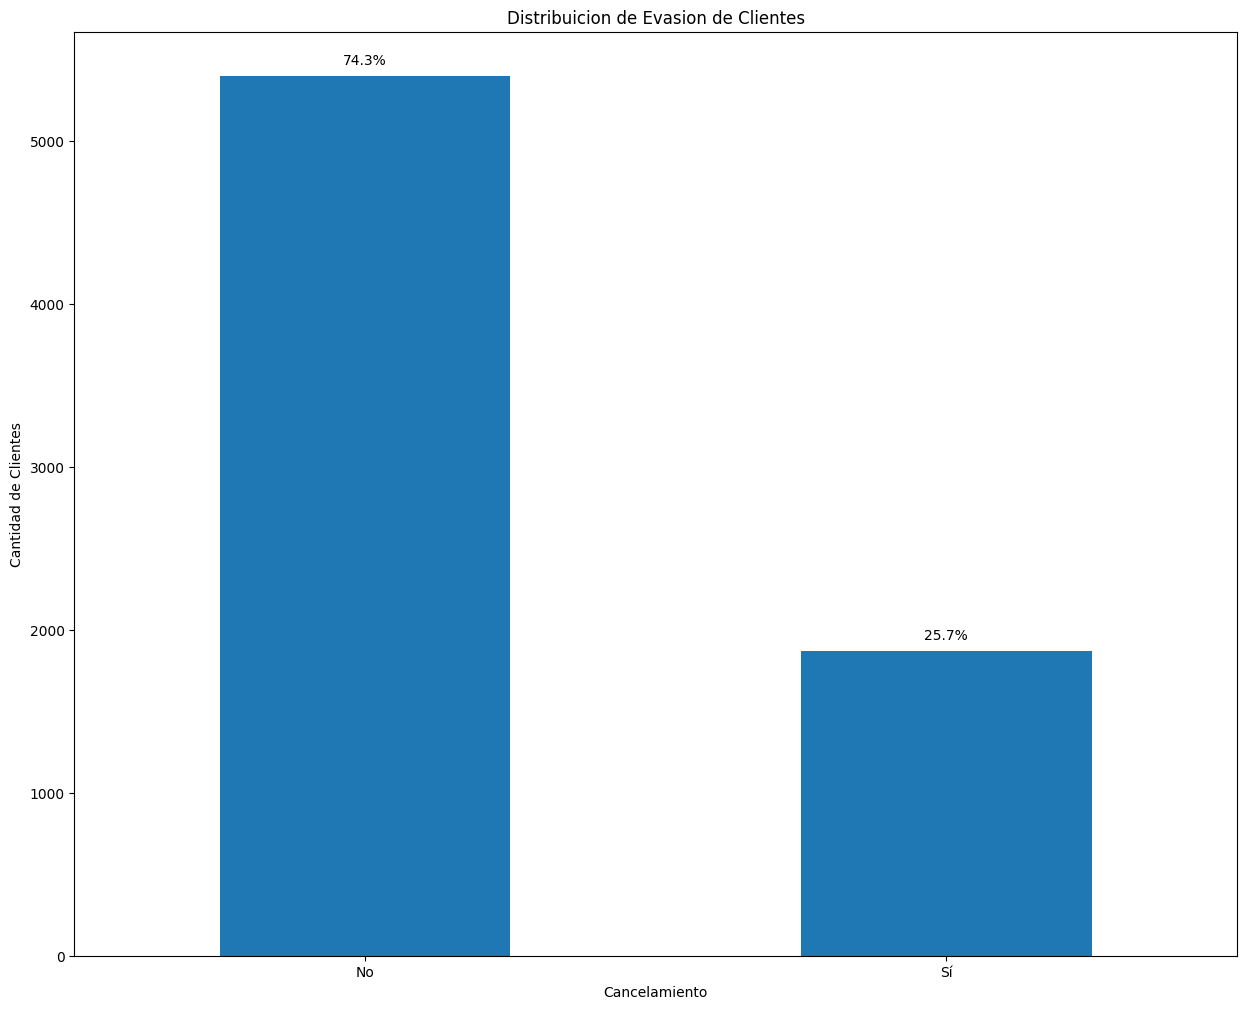

In [225]:

plt.figure(figsize=(15, 12))
churn_counts = df['Abandono'].value_counts()
churn_percentages = (churn_counts / len(df)) * 100

ax = churn_counts.plot(kind='bar')
plt.title('Distribuicion de Evasion de Clientes')
plt.xlabel('Cancelamiento')
plt.ylabel('Cantidad de Clientes')
plt.xticks(ticks=[0, 1], labels=['No', 'Sí'], rotation=0) # Personalizo el gráfico para etiquetas SI/NO

for i, percentage in enumerate(churn_percentages):
    ax.text(i, churn_counts.iloc[i] + 50, f'{percentage:.1f}%', ha='center', va='bottom')

plt.show()

In [226]:
import plotly.express as px

<Figure size 640x480 with 0 Axes>

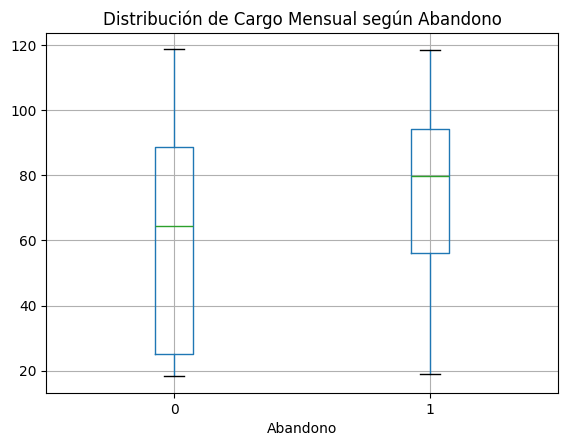

In [227]:

# Abandono vs cargo mensual
plt.figure()
df.boxplot(column='CargoMensual', by='Abandono')
plt.title("Distribución de Cargo Mensual según Abandono")
plt.suptitle("")
plt.show()


- Clientes con mayores cargos mensuales tienden a abandonar más.

Posible explicación:

*   percepción de alto costo
*   servicios poco utilizados

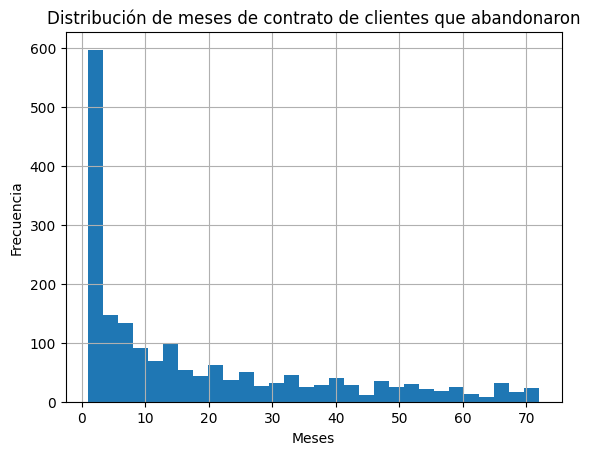

In [228]:

# Antigüedad del cliente vs Abandono
plt.figure()
df[df['Abandono']==1]['MesesContrato'].hist(bins=30)
plt.title("Distribución de meses de contrato de clientes que abandonaron")
plt.xlabel("Meses")
plt.ylabel("Frecuencia")
plt.show()


- Los primeros meses son críticos para la retención. La mayor cantidad de abandonos se generan en los primeros meses de contrato.

Gran parte del abandono ocurre durante los primeros meses del servicio.

Esto indica problemas potenciales en:
- onboarding
- satisfacción inicial
- instalación o servicio técnico

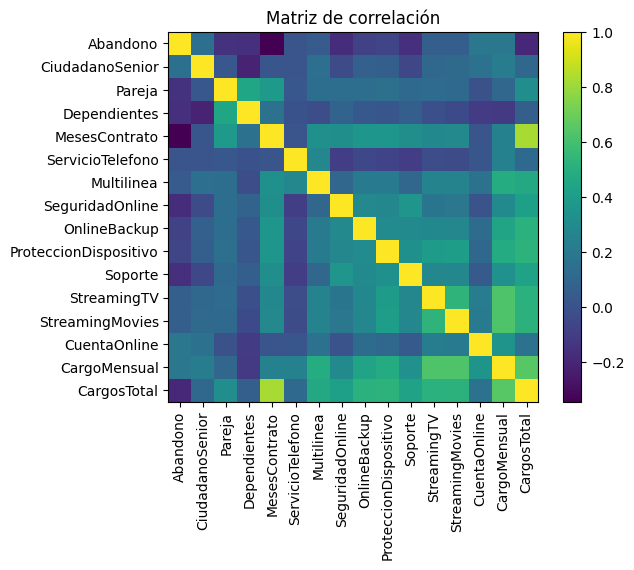

In [229]:

# Matriz de correlación de variables numéricas
corr = df.select_dtypes(include=['int64','float64']).corr()

plt.figure()
plt.imshow(corr)
plt.title("Matriz de correlación")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()


- Variables como:

*   cargo mensual
*   antigüedad
*   cargos totales


pueden ser relevantes para modelos de machine learning.

In [230]:
# Grafico la relación entre abandono y género

df_plot = df.copy()
df_plot['Abandono'] = df_plot['Abandono'].map({0: 'No', 1: 'Sí'})
px.histogram(df_plot, x='Genero', text_auto=True, color='Abandono', barmode='group')

- No se detectan diferencias significativas entre géneros, por lo que esta variable **no parece ser un fuerte predictor de abandono.**

In [231]:

df_plot = df.copy()
df_plot['Abandono'] = df_plot['Abandono'].map({0: 'No', 1: 'Sí'})
px.histogram(df_plot, x = 'TipoContrato', text_auto = True, color = 'Abandono', barmode = 'group')

- Los contratos de largo plazo generan mayor fidelización.

In [232]:
df_plot = df.copy()
df_plot['Abandono'] = df_plot['Abandono'].map({0: 'No', 1: 'Sí'})
px.histogram(df_plot, x = 'MetodoPago',  text_auto = True, color = 'Abandono', barmode = 'group')

- Los pagos automáticos aumentan compromiso del cliente.

#📄Informe final

# 📄 Informe Final – Análisis de Evasión de Clientes (Abandono) en Telecom X

## 1. Introducción

El presente análisis tiene como objetivo comprender los factores asociados a la **evasión de clientes (Abandono)** en la empresa Telecom X. La evasión de clientes corresponde al fenómeno en el cual los usuarios cancelan o dejan de utilizar los servicios de la compañía, lo que representa un problema relevante para el negocio debido a la pérdida de ingresos y al aumento de los costos asociados a la adquisición de nuevos clientes.

En este contexto, el propósito del análisis es **explorar los datos disponibles para identificar patrones y variables que puedan estar relacionadas con el abandono de clientes**. Este trabajo constituye un primer paso dentro de un proceso analítico más amplio que podría posteriormente incluir el desarrollo de **modelos predictivos de Abandono** y el diseño de **estrategias de retención de clientes**.

---

## 2. Limpieza y Tratamiento de Datos

Los datos utilizados en este análisis fueron obtenidos desde una fuente externa en formato JSON mediante una solicitud a una API. Posteriormente, se realizó un proceso de preparación de los datos siguiendo principios básicos de **ETL (Extracción, Transformación y Carga)**.

Las principales tareas realizadas en esta etapa fueron:

* **Extracción de datos** desde la API utilizando la biblioteca `requests`.
* **Normalización del archivo JSON** mediante `pandas.json_normalize()` para convertir la estructura en un DataFrame.
* **Revisión de la estructura del dataset**, incluyendo tipos de datos y descripción de variables.
* **Renombrado de columnas** para facilitar la interpretación y análisis posterior.
* **Identificación de valores únicos** en variables categóricas con el fin de detectar posibles inconsistencias.
* **Traducción de variables categóricas** desde inglés a español para mejorar la claridad del análisis.
* **Detección de valores duplicados** para asegurar la integridad del dataset.
* **Identificación de valores nulos y valores vacíos**, incluyendo cadenas con espacios en blanco.
* **Conversión de variables categóricas dicotómicas a formato binario**, facilitando su uso en análisis estadísticos o modelos predictivos.
* **Conversión de variables numéricas**, como los cargos totales, para asegurar que los cálculos posteriores se realicen correctamente.

Este proceso permitió obtener un **dataset limpio, estructurado y adecuado para el análisis exploratorio de datos**.

---

## 3. Análisis Exploratorio de Datos (EDA)

Una vez preparado el dataset, se realizó un **Análisis Exploratorio de Datos (EDA)** con el objetivo de identificar patrones, tendencias y posibles relaciones entre las variables del dataset y el abandono de clientes.

Entre los principales análisis realizados se incluyen:

### Tasa general de abandono

Se calculó la proporción total de clientes que han abandonado el servicio. Los resultados indican que **aproximadamente uno de cada cuatro clientes ha cancelado su servicio**, lo que representa una tasa de abandono considerable para la empresa.

---

### Relación entre abandono y variables demográficas

Se analizó la relación entre el abandono y variables como el **género del cliente**. Los resultados muestran que **no existen diferencias significativas entre géneros**, lo que sugiere que esta variable no es un factor determinante en la evasión.

---

### Abandono según antigüedad del cliente

Se exploró la relación entre la **cantidad de meses que un cliente ha permanecido en la empresa** y la probabilidad de abandono.

Los resultados muestran que:

* Los clientes con **menor antigüedad presentan mayor probabilidad de cancelar el servicio**.
* A medida que aumenta el tiempo de permanencia, la probabilidad de abandono disminuye.

Esto sugiere que **los primeros meses de relación con el cliente son críticos para la retención**.

---

### Abandono según tipo de contrato

Se analizó cómo varía la tasa de abandono según el tipo de contrato del cliente:

* Contrato mensual
* Contrato anual
* Contrato bianual

Los resultados indican que **los clientes con contratos mensuales presentan una tasa de abandono considerablemente mayor** en comparación con aquellos con contratos de mayor duración.

Esto sugiere que **los contratos de largo plazo pueden favorecer la fidelización del cliente**.

---

### Abandono según servicio de internet

También se evaluó la relación entre el tipo de servicio de internet contratado y el abandono del servicio. Este análisis permite identificar si determinados tipos de servicio presentan mayores tasas de evasión.

---

### Abandono según método de pago

El análisis del **método de pago** muestra que existen diferencias en las tasas de abandono dependiendo del tipo de pago utilizado por los clientes. En particular, los métodos de pago no automáticos parecen asociarse con mayores tasas de cancelación.

---

### Análisis de cargos mensuales

Se exploró la relación entre el **cargo mensual del servicio y el abandono**. Los resultados sugieren que los clientes con **cargos mensuales más altos presentan una tendencia ligeramente mayor a cancelar el servicio**, lo que podría indicar una relación entre percepción de costo y decisión de abandono.

---

### Análisis de correlación entre variables numéricas

Se generó una **matriz de correlación** para explorar las relaciones entre variables numéricas del dataset.

Este análisis permitió observar que variables como:

* **Meses de contrato**
* **Cargo mensual**
* **Cargos totales acumulados**

presentan relaciones que podrían ser relevantes para futuros análisis o modelos predictivos de abandono.

---

## 4. Conclusiones e Insights

A partir del análisis exploratorio realizado se identificaron varios hallazgos relevantes:

1. **La tasa de abandono es relativamente alta**, lo que sugiere la necesidad de implementar estrategias de retención.

2. **La antigüedad del cliente es un factor clave en el abandono**. Los clientes con menos tiempo en la empresa presentan mayor probabilidad de abandonar el servicio.

3. **El tipo de contrato influye significativamente en la evasión**. Los contratos mensuales muestran una mayor tasa de abandono en comparación con contratos de largo plazo.

4. **Los cargos mensuales más altos podrían estar asociados a mayor probabilidad de cancelación**, posiblemente debido a una menor percepción de valor del servicio.

5. **El método de pago también muestra diferencias en las tasas de abandono**, lo que podría reflejar distintos niveles de compromiso por parte del cliente.

Estos resultados proporcionan información útil para comprender mejor el comportamiento de los clientes y orientar futuras estrategias de negocio.

---

## 5. Recomendaciones

En base a los resultados obtenidos, se sugieren las siguientes acciones estratégicas para reducir la evasión de clientes:

**1. Incentivar contratos de largo plazo**
Ofrecer descuentos o beneficios adicionales a los clientes que opten por contratos anuales o bianuales.

**2. Mejorar la experiencia de los primeros meses**
Dado que el abandono se concentra en clientes nuevos, se recomienda implementar programas de **onboarding y seguimiento temprano del cliente**.

**3. Promover métodos de pago automáticos**
Los pagos automáticos podrían aumentar el compromiso del cliente y reducir la probabilidad de abandono.

**4. Evaluar la estructura de precios y valor percibido**
Analizar si los clientes con cargos más altos perciben adecuadamente el valor del servicio ofrecido.

**5. Implementar modelos predictivos de abandono**
Utilizar técnicas de **Machine Learning** para identificar clientes con alta probabilidad de abandono y aplicar estrategias de retención de manera anticipada.

---

## Consideraciones Finales

Este análisis exploratorio constituye una **base inicial para comprender el fenómeno de abandono en Telecom X**. Los resultados obtenidos permiten identificar variables relevantes y posibles factores asociados a la evasión de clientes.

Como próximos pasos, se recomienda profundizar el análisis mediante **modelos predictivos, segmentación de clientes y análisis de comportamiento**, lo que permitirá desarrollar estrategias más efectivas para mejorar la retención y fortalecer la relación con los clientes.
